In [10]:
import requests
import numpy as np
import skimage
import matplotlib.pyplot as plt

In [288]:
img_data = requests.get('https://www.cleardarksky.com/c/DrnbrnObILcsk.gif?c=579625').content
with open('thing.jpg', 'wb') as handler:
    handler.write(img_data)

In [24]:
img = skimage.io.imread('thing.jpg')[0]

In [91]:
img.shape


(276, 1270, 3)

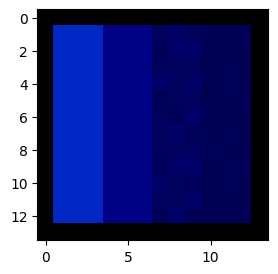

In [309]:
centerx = 140+14*11
centery = 131
plt.figure(figsize=(3,3))
plt.imshow(img[centery-7:centery+7,centerx-7:centerx+7])

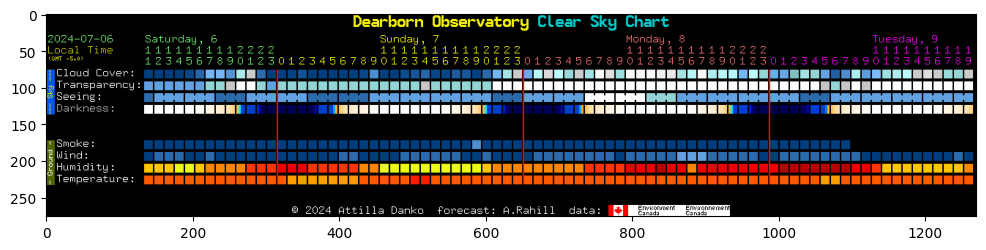

In [34]:
plt.figure(figsize=(12,5))
plt.imshow(img)


In [269]:
cols = [140 + 14*i for i in range(80)]

cloud_cover_row = 83
cloud_cover_colors = img[cloud_cover_row][cols] # array of values 

transparency_row = 99
transparency_colors = img[transparency_row][cols] # array of values 

seeing_row = 115
seeing_colors = img[seeing_row][cols] # array of values 

darkness_row = 131
darkness_colors = img[darkness_row][cols] # array of values 

In [307]:
# get normalized colors
cloud_vals = np.linalg.norm(cloud_cover_colors, axis=1)
transparency_vals = np.linalg.norm(transparency_colors, axis=1)
seeing_vals = np.linalg.norm(seeing_colors, axis=1)

# select only darkness times
nighttimes = np.where(np.linalg.norm(darkness_colors, axis=1) < 115)

# get scores for all times
scores = cloud_vals + transparency_vals + seeing_vals
# reduce to just nighttime
scores = scores[nighttimes]


array([ 835.43171911,  730.08544517,  769.60978807,  776.35184038,
        797.59802187,  681.0308727 , 1007.96030246,  999.52911835,
       1047.86003428, 1130.84547846, 1114.08879584, 1132.50279075,
       1132.50279075, 1070.85482655, 1047.86003428, 1039.58421681,
       1036.68832842, 1001.03209923])

In [ ]:
# find first dayswitch


In [308]:
nighttimes

(array([11, 12, 13, 14, 15, 16, 35, 36, 37, 38, 39, 40, 59, 60, 61, 62, 63,
        64]),)

In [299]:
import datetime
from pytz import timezone
now = datetime.datetime.now()
#now.astimezone(timezone('America/Chicago'))
now

datetime.datetime(2024, 7, 6, 18, 33, 23, 781193)

In [290]:
import requests
from bs4 import BeautifulSoup
from datetime import datetime

def get_last_updated(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # Check for meta tags that might contain the last update time
    meta_tags = soup.find_all('meta')
    for tag in meta_tags:
        if 'last-modified' in tag.get('name', '').lower() or 'last-modified' in tag.get('http-equiv', '').lower():
            last_modified = tag.get('content')
            return f"Last updated time (from meta tag): {last_modified}"
        
      
    # Check for common elements where the last update time might be mentioned
    possible_selectors = [
        'time', 
        'span', 
        'div', 
        'p'
    ]
    for selector in possible_selectors:
        elements = soup.find_all(selector)
        for element in elements:
            if 'updated' in element.text.lower() or 'modified' in element.text.lower():
                return f"Last updated time (from page content): {element.text.strip()}"
    
    # If none of the above work, check the HTTP headers
    if 'Last-Modified' in response.headers:
        last_modified = response.headers['Last-Modified']
        last_modified_dt = datetime.strptime(last_modified, '%a, %d %b %Y %H:%M:%S %Z')
        return f"Last updated time (from HTTP header): {last_modified_dt}"

    return "Could not determine the last update time."

url = 'https://www.cleardarksky.com/c/DrnbrnObILcsk.gif?c=579625'
print(get_last_updated(url))

Could not determine the last update time.


In [ ]:
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')


In [ ]:
#colors
clear = [0,62,126]
tenp = [18,82,146]
twentyp = []

In [260]:
cloud_cover_colors[15]

array([ 18,  82, 146], dtype=uint8)

In [254]:
np.unique(cloud_cover_colors, return_index=True, axis=0)

(array([[  0,  62, 126],
        [  3,  67, 131],
        [  8,  72, 136],
        [ 13,  77, 141],
        [ 18,  82, 146],
        [ 23,  87, 151],
        [ 28,  92, 156],
        [ 33,  97, 161],
        [ 38, 102, 166],
        [ 43, 107, 171],
        [ 78, 142, 206],
        [ 83, 147, 211],
        [ 93, 157, 221],
        [ 98, 162, 226],
        [103, 167, 231],
        [108, 172, 236],
        [118, 182, 246],
        [123, 187, 251],
        [128, 192, 192],
        [148, 212, 212],
        [153, 217, 217],
        [158, 222, 222],
        [163, 227, 227],
        [168, 232, 232],
        [173, 237, 237],
        [183, 247, 247],
        [188, 252, 252],
        [203, 203, 203],
        [218, 218, 218],
        [223, 223, 223],
        [233, 233, 233],
        [238, 238, 238],
        [246, 246, 246],
        [251, 251, 251]], dtype=uint8),
 array([ 0, 14,  4, 25, 15, 26, 30, 67,  5, 11, 22,  8, 70, 66, 62, 37,  6,
        71, 63, 60, 41, 46, 35,  9, 55, 38, 40, 10, 39, 45,

In [243]:
cloud_cover_colors

array([[  0,  62, 126],
       [  0,  62, 126],
       [  0,  62, 126],
       [  0,  62, 126],
       [  8,  72, 136],
       [ 38, 102, 166],
       [118, 182, 246],
       [118, 182, 246],
       [ 83, 147, 211],
       [168, 232, 232],
       [203, 203, 203],
       [ 43, 107, 171],
       [  0,  62, 126],
       [  0,  62, 126],
       [  3,  67, 131],
       [ 18,  82, 146],
       [  0,  62, 126],
       [  0,  62, 126],
       [  0,  62, 126],
       [  0,  62, 126],
       [  0,  62, 126],
       [  8,  72, 136],
       [ 78, 142, 206],
       [  0,  62, 126],
       [  0,  62, 126],
       [ 13,  77, 141],
       [ 23,  87, 151],
       [ 38, 102, 166],
       [  8,  72, 136],
       [  8,  72, 136],
       [ 28,  92, 156],
       [ 23,  87, 151],
       [  3,  67, 131],
       [ 43, 107, 171],
       [118, 182, 246],
       [163, 227, 227],
       [203, 203, 203],
       [108, 172, 236],
       [183, 247, 247],
       [218, 218, 218],
       [188, 252, 252],
       [153, 217

In [218]:
arr = np.arange(6).reshape(2, 3)
arr
np.place(arr, arr>2, [44, 55])
arr

array([[ 0,  1,  2],
       [44, 55, 44]])

In [223]:
full_white = [255,255,255]
is_white = np.all(transparency_colors == full_white, axis=1)
is_white
#np.place(transparency_colors, [is_white], 0)
is_white

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True, False,  True,  True,  True, False,  True, False, False,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True, False,  True, False, False, False,  True, False,  True,
        True, False,  True,  True,  True,  True, False,  True, False])

In [237]:
np.where(is_white, 'w','n')

array(['n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'w', 'n', 'n', 'n',
       'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n',
       'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'w', 'w', 'w', 'w',
       'w', 'n', 'w', 'n', 'w', 'w', 'w', 'n', 'w', 'w', 'w', 'n', 'w',
       'n', 'n', 'w', 'w', 'w', 'w', 'n', 'n', 'w', 'w', 'w', 'w', 'n',
       'w', 'n', 'n', 'n', 'w', 'n', 'w', 'w', 'n', 'w', 'w', 'w', 'w',
       'n', 'w', 'n'], dtype='<U1')

In [233]:
arr = np.place(arr, is_white, 'White')
arr

In [234]:
arr

In [171]:
transparency_colors

array([[ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [148, 212, 212],
       [148, 212, 212],
       [198, 198, 198],
       [255, 255, 255],
       [251, 251, 251],
       [148, 212, 212],
       [ 98, 162, 226],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [198, 198, 198],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [251, 251, 251],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [251, 251, 251],
       [255, 255

In [186]:
transparency_colors = np.append(transparency_colors, np.array([[0,255,0]]), axis=0)

In [191]:
transparency_colors[35]

array([255, 255, 255])

In [ ]:
all

In [194]:
transparency_colors==full_white

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [ True,  True,  True],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [Fa

In [204]:
is_in_list = np.all(transparency_colors == full_white, axis=1)

In [205]:
is_in_list

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True, False,  True,  True,  True, False,  True, False, False,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True, False,  True, False, False, False,  True, False,  True,
        True, False,  True,  True,  True,  True, False,  True, False])

In [200]:
transparency_colors[transparency_colors==full_white]

array([255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
       255, 255, 255])

In [198]:
np.where(np.array_equal(transparency_colors, full_white))

/var/folders/dj/vkllzxx9595cw8tb3b99b95w0000gn/T/ipykernel_11768/1297694782.py:1: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  np.where(np.array_equal(transparency_colors, full_white))


(array([], dtype=int64),)

In [165]:
transparency_colors = np.append(transparency_colors, np.array([255,0,0]))

In [175]:
all(transparency_colors==full_white)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [156]:
full_white = [255,255,255]
np.putmask(transparency_colors, transparency_colors==full_white, '0')

In [157]:
transparency_colors

array([[ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [ 98, 162, 226],
       [148, 212, 212],
       [148, 212, 212],
       [198, 198, 198],
       [  0,   0,   0],
       [251, 251, 251],
       [148, 212, 212],
       [ 98, 162, 226],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [198, 198, 198],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [148, 212, 212],
       [251, 251, 251],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [251, 251, 251],
       [  0,   0

In [131]:
darkness_colors[0]

array([255, 255, 255], dtype=uint8)

In [129]:
transparency_colors[0]

array([ 98, 162, 226], dtype=uint8)

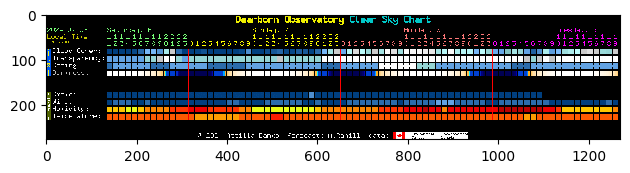

In [22]:
skimage.io.imshow(img[0])
skimage.io.show()